# Supplementary Notebook S2: KE/EKE Trend-Window Comparison (Full period vs Since 2016)

This notebook now focuses only on comparing KE/EKE trends computed over two time windows:

1. Full available period.
2. Since 2016.

## Methodology
- Trend estimator: Theil-Sen robust median slope.
- Significance test: Mann-Kendall with autocorrelation correction (Yue and Wang, 2004).
- Significance labels: `* p<0.05`, `** p<0.01`, `*** p<0.001`.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Paths
def find_repo_root(start=Path.cwd()):
    p = start.resolve()
    while True:
        if (p / 'scripts').exists() and (p / 'outputs').exists():
            return p
        if p == p.parent:
            return start.resolve()
        p = p.parent

REPO_ROOT = find_repo_root()
print(f'Auto-detected REPO_ROOT: {REPO_ROOT}')

INPUT_TREND_DIR = REPO_ROOT / 'outputs' / 'trends'
INPUT_HP_DIR = REPO_ROOT / 'outputs' / 'monthly_half-power_points'
INPUT_2D_TRENDS_FILE = INPUT_TREND_DIR / 'ke_eke_2d_trends_since2016.nc'
PLOT_DIR = REPO_ROOT / 'outputs' / 'plots' / 'trends_split'
FIG_DIR = REPO_ROOT / 'figures' / 'supplementary'   # publication figures (tracked by git)
FIG_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

REGION_ORDER = ['Indian', 'Pacific', 'Atlantic', 'ACC']
REGION_COLORS = {
    'Indian': '#2A9D8F',
    'Pacific': '#457B9D',
    'Atlantic': '#E07A5F',
    'ACC': '#2F3E46',
}

STYLE = {
    'raw_alpha': 0.18,
    'raw_lw': 0.7,
    'smooth_lw': 1.9,
    'trend_lw': 1.4,
    'grid_alpha': 0.18,
    'grid_lw': 0.5,
    'axis_label_size': 11,
    'title_size': 11,
    'tick_size': 9,
    'annot_size': 9,
    'panel_size': 11,
    'neutral': '#7A8288',
    'ke': "#e96c6a",
    'eke': '#2A9D8F',
    'trend_sig': '#1F2933',
}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':         10,
    'axes.labelsize':    STYLE['axis_label_size'],
    'axes.titlesize':    STYLE['title_size'],
    'axes.titleweight':  'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'grid.alpha':        0.18,
    'grid.linewidth':    0.5,
    'xtick.labelsize':   STYLE['tick_size'],
    'ytick.labelsize':   STYLE['tick_size'],
    'legend.fontsize':   8,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#cccccc',
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

def panel_label(ax, label):
    ax.text(
        0.015,
        0.985,
        f'({label})',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=STYLE['panel_size'],
        fontweight='semibold',
        color='#1F2933',
    )

def base_timeseries_style(ax):
    ax.grid(alpha=STYLE['grid_alpha'], lw=STYLE['grid_lw'])
    ax.tick_params(length=3.0, width=0.7, color='#67727A')

def assign_sector(lon):
    lon360 = lon % 360
    if lon360 >= 290 or lon360 < 20:
        return 'Atlantic'
    if 20 <= lon360 < 147:
        return 'Indian'
    if 147 <= lon360 < 290:
        return 'Pacific'
    return 'Unknown'

def stars(p):
    if not np.isfinite(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''

def theil_sen_with_ci(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return {'slope': np.nan, 'intercept': np.nan, 'lo': np.nan, 'hi': np.nan, 'se': np.nan}

    res = stats.theilslopes(y[m], x[m], alpha=0.95)
    slope = float(res.slope)
    intercept = float(res.intercept)
    lo = float(res.low_slope)
    hi = float(res.high_slope)
    se = (hi - lo) / (2 * 1.96) if np.isfinite(lo) and np.isfinite(hi) else np.nan
    return {'slope': slope, 'intercept': intercept, 'lo': lo, 'hi': hi, 'se': se}

def _mk_s_var(y):
    n = len(y)
    s = 0
    for i in range(n - 1):
        s += np.sign(y[i + 1:] - y[i]).sum()

    _, counts = np.unique(y, return_counts=True)
    tie_term = np.sum(counts * (counts - 1) * (2 * counts + 5))
    var_s = (n * (n - 1) * (2 * n + 5) - tie_term) / 18.0
    return s, var_s

def mann_kendall_yue_wang(y, alpha=0.05, max_lag=12):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    n = len(y)
    if n < 5:
        return {'tau': np.nan, 'p': np.nan, 'n_eff': np.nan}

    s, var_s = _mk_s_var(y)
    tau = s / (0.5 * n * (n - 1))

    # Detrend before autocorrelation estimation to avoid trend leakage into rho.
    x = np.arange(n, dtype=float)
    ts = theil_sen_with_ci(x, y)
    if np.isfinite(ts['slope']) and np.isfinite(ts['intercept']):
        y_for_ac = y - (ts['slope'] * x + ts['intercept'])
    else:
        y_for_ac = y - np.nanmean(y)

    ranks = stats.rankdata(y_for_ac)
    r = ranks - np.mean(ranks)
    denom = np.sum(r**2)
    if denom <= 0:
        return {'tau': tau, 'p': np.nan, 'n_eff': np.nan}

    max_lag = min(max_lag, n - 2)
    sig_rhos = []
    for k in range(1, max_lag + 1):
        num = np.sum(r[:-k] * r[k:])
        rho_k = num / denom
        crit = stats.norm.ppf(1 - alpha / 2) / np.sqrt(n)
        if np.abs(rho_k) > crit:
            sig_rhos.append((k, rho_k))

    if len(sig_rhos) == 0:
        n_eff = n
    else:
        corr_sum = np.sum([(1 - k / n) * rho for k, rho in sig_rhos])
        n_eff = n / (1 + 2 * corr_sum)
        n_eff = np.clip(n_eff, 2, n)

    var_s_adj = var_s * (n / n_eff)
    if s > 0:
        z = (s - 1) / np.sqrt(var_s_adj)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s_adj)
    else:
        z = 0.0
    p = 2 * stats.norm.sf(abs(z))

    return {'tau': float(tau), 'p': float(p), 'n_eff': float(n_eff)}

print(f'Trend input: {INPUT_TREND_DIR}')
print(f'2D fields input: {INPUT_HP_DIR}')
print(f'Precomputed 2D trend file: {INPUT_2D_TRENDS_FILE}')
print(f'Output plots: {PLOT_DIR}')

Auto-detected REPO_ROOT: repository
Trend input: outputs/trends
2D fields input: outputs/monthly_half-power_points
Precomputed 2D trend file: outputs/trends/ke_eke_2d_trends_since2016.nc
Output plots: outputs/plots/trends_split


In [2]:
# Load regional KE/EKE time series and build trend tables for two windows.
energy_ts = pd.read_csv(INPUT_TREND_DIR / 'energy_field_timeseries.csv')
if 'sector' in energy_ts.columns and 'region' not in energy_ts.columns:
    energy_ts = energy_ts.rename(columns={'sector': 'region'})
if 'decimal_year' not in energy_ts.columns:
    energy_ts['decimal_year'] = energy_ts['year'] + (energy_ts['month'] - 0.5) / 12.0

# Keep canonical naming used across notebooks.
energy_ts['region'] = energy_ts['region'].replace({'Whole SO': 'ACC'})
energy_ts = energy_ts[energy_ts['region'].isin(REGION_ORDER)].copy()
energy_ts = energy_ts.sort_values(['region', 'decimal_year']).reset_index(drop=True)

def build_trend_table(df, window_name):
    rows = []
    for region in REGION_ORDER:
        grp = df[df['region'] == region].sort_values('decimal_year')
        x = grp['decimal_year'].values.astype(float)

        for col, label in [('mean_ke', 'KE'), ('mean_eke', 'EKE')]:
            y = grp[col].values.astype(float) * 1e4  # convert to cm^2 s^-2
            ts = theil_sen_with_ci(x, y)
            mk = mann_kendall_yue_wang(y)
            ci95 = 1.96 * ts['se'] if np.isfinite(ts['se']) else np.nan

            rows.append({
                'window': window_name,
                'region': region,
                'variable': label,
                'n': int(np.isfinite(y).sum()),
                'slope': ts['slope'],
                'ci95': ci95,
                'mk_p': mk['p'],
                'sig': stars(mk['p']),
            })
    return pd.DataFrame(rows)

trend_full = build_trend_table(energy_ts, 'Full period')
trend_2016 = build_trend_table(energy_ts[energy_ts['decimal_year'] >= 2016].copy(), 'Since 2016')
trend_compare = pd.concat([trend_full, trend_2016], ignore_index=True)

print('Trend windows generated:')
print(trend_compare.groupby('window')['n'].describe()[['count', 'min', 'max']])
print('')
print('Sample rows:')
print(trend_compare.head(8))

Trend windows generated:
             count    min    max
window                          
Full period    8.0  300.0  300.0
Since 2016     8.0  120.0  120.0

Sample rows:
        window    region variable    n     slope      ci95          mk_p  sig
0  Full period    Indian       KE  300  0.795193  0.200584  8.616215e-04  ***
1  Full period    Indian      EKE  300  1.251586  0.294034  5.336902e-04  ***
2  Full period   Pacific       KE  300  0.788313  0.104394  1.312474e-06  ***
3  Full period   Pacific      EKE  300  1.039430  0.149309  5.506165e-05  ***
4  Full period  Atlantic       KE  300  1.138897  0.263958  1.568124e-03   **
5  Full period  Atlantic      EKE  300  2.002269  0.380989  8.177938e-04  ***
6  Full period       ACC       KE  300  0.877399  0.133482  5.018718e-07  ***
7  Full period       ACC      EKE  300  1.338136  0.190163  1.829133e-05  ***


## Figure A1: Trend Comparison (Full Period vs Since 2016)

This figure contains only the trend comparison requested:

- Regional KE trends: full period vs since 2016.
- Regional EKE trends: full period vs since 2016.
- 95% CI error bars from the Theil-Sen slope uncertainty.
- Significance stars from Mann-Kendall Yue-Wang p-values.

Outputs:
- `outputs/plots/trends_split/figA1_trend_comparison_full_vs_since2016.png`
- `outputs/trends/trend_comparison_full_vs_since2016.csv`

Saved trend table: outputs/trends/trend_comparison_full_vs_since2016.csv


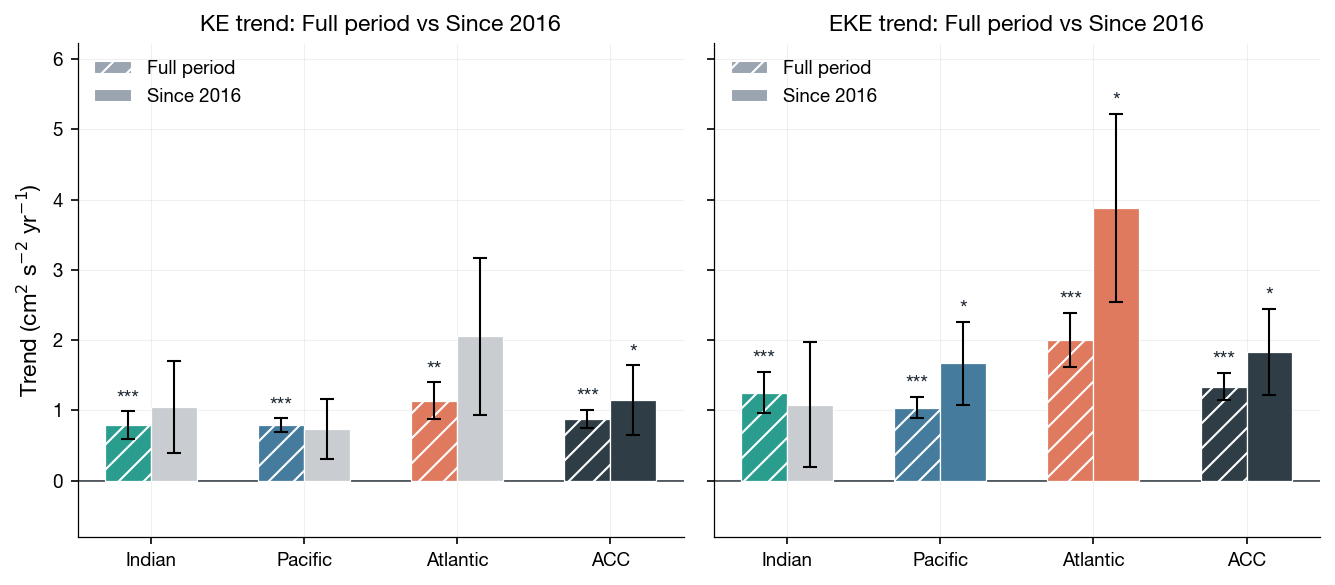

Saved: outputs/plots/trends_split/figA1_trend_comparison_full_vs_since2016.png

Trend summary (slope and p-value):
                           mk_p                  slope           
window              Full period Since 2016 Full period Since 2016
region   variable                                                
ACC      EKE       1.829133e-05   0.026070    1.338136   1.829266
         KE        5.018718e-07   0.019440    0.877399   1.146364
Atlantic EKE       8.177938e-04   0.026752    2.002269   3.876451
         KE        1.568124e-03   0.084085    1.138897   2.052986
Indian   EKE       5.336902e-04   0.265775    1.251586   1.081544
         KE        8.616215e-04   0.125115    0.795193   1.048871
Pacific  EKE       5.506165e-05   0.041220    1.039430   1.668978
         KE        1.312474e-06   0.150113    0.788313   0.735209


In [5]:
# Single figure with two subplots (KE and EKE), Full period vs Since 2016, shared y-scale.
from matplotlib.patches import Patch

plot_df = trend_compare.copy()

out_csv = INPUT_TREND_DIR / 'trend_comparison_full_vs_since2016.csv'
plot_df.to_csv(out_csv, index=False)
print(f'Saved trend table: {out_csv}')

regions = REGION_ORDER
xpos = np.arange(len(regions))
w = 0.30

# Shared y-limits across both panels (global min/max over all slopes ± CI)
slopes_all = plot_df['slope'].values.astype(float)
ci_all = np.where(np.isfinite(plot_df['ci95'].values.astype(float)),
                  plot_df['ci95'].values.astype(float), 0.0)
y_hi = np.nanmax(slopes_all + ci_all)
y_lo = np.nanmin(slopes_all - ci_all)
pad = (y_hi - y_lo) * 0.20
ylim = (min(y_lo - pad, -0.05), y_hi + pad * 1)  # extra top room for significance stars

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

for ax, var in zip(axes, ['KE', 'EKE']):
    dvar = plot_df[plot_df['variable'] == var].copy()
    d_full = dvar[dvar['window'] == 'Full period'].set_index('region').reindex(regions)
    d_2016 = dvar[dvar['window'] == 'Since 2016'].set_index('region').reindex(regions)

    full_colors = [
        REGION_COLORS[r] if np.isfinite(d_full.loc[r, 'mk_p']) and d_full.loc[r, 'mk_p'] < 0.05 else '#C9CDD1'
        for r in regions
    ]
    since_colors = [
        REGION_COLORS[r] if np.isfinite(d_2016.loc[r, 'mk_p']) and d_2016.loc[r, 'mk_p'] < 0.05 else '#C9CDD1'
        for r in regions
    ]

    ax.bar(
        xpos - w / 2,
        d_full['slope'].values,
        yerr=d_full['ci95'].values,
        width=w,
        color=full_colors,
        hatch='//',
        edgecolor='white',
        linewidth=0.6,
        error_kw={'lw': 1.0, 'capsize': 3.5, 'capthick': 1.0},
        zorder=3,
    )
    ax.bar(
        xpos + w / 2,
        d_2016['slope'].values,
        yerr=d_2016['ci95'].values,
        width=w,
        color=since_colors,
        alpha=1,
        edgecolor='white',
        linewidth=0.6,
        error_kw={'lw': 1.0, 'capsize': 3.5, 'capthick': 1.0},
        zorder=3,
    )

    yr = np.nanmax(np.abs(np.r_[d_full['slope'].values, d_2016['slope'].values]))
    yr = max(yr if np.isfinite(yr) else 0.0, 1e-6)
    for i, r in enumerate(regions):
        for xbar, sdf in [(xpos[i] - w / 2, d_full), (xpos[i] + w / 2, d_2016)]:
            s = sdf.loc[r, 'slope']
            e = sdf.loc[r, 'ci95'] if np.isfinite(sdf.loc[r, 'ci95']) else 0.0
            p = sdf.loc[r, 'mk_p']
            st = stars(p)
            if st and np.isfinite(s):
                ytxt = s + e + 0.01 * yr if s >= 0 else s - e - 0.01 * yr
                ax.text(
                    xbar, ytxt, st,
                    ha='center', va='bottom' if s >= 0 else 'top',
                    fontsize=10.5, fontweight='semibold', color='#1F2933',
                )

    ax.axhline(0, color='#495057', lw=0.9, zorder=1)
    ax.set_xticks(xpos)
    ax.set_xticklabels(regions)
    ax.set_ylim(ylim)
    ax.grid(axis='y', alpha=STYLE['grid_alpha'], lw=STYLE['grid_lw'])
    ax.set_title(f'{var} trend: Full period vs Since 2016')
    legend_handles = [
        Patch(facecolor='#9AA5B1', hatch='//', edgecolor='white', label='Full period'),
        Patch(facecolor='#9AA5B1', alpha=1, edgecolor='white', label='Since 2016'),
    ]
    ax.legend(handles=legend_handles, frameon=False, fontsize=9, loc='upper left')

axes[0].set_ylabel(r'Trend (cm$^2$ s$^{-2}$ yr$^{-1}$)')

fig.tight_layout()
# Supplementary figure 'KE_EKE_trends_since2016', bottom panels (comparison bars)
out_fig = FIG_DIR / 'KE_EKE_trends_since2016_bars.png'
fig.savefig(out_fig, dpi=400, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')

# Compact numeric summary
summary = plot_df.pivot_table(
    index=['region', 'variable'],
    columns='window',
    values=['slope', 'mk_p'],
    aggfunc='first',
)
print('\nTrend summary (slope and p-value):')
print(summary)


## Figure A2: Since-2016 Trend Maps and Difference Maps

This section adds 2D maps for:

- Since-2016 trend fields (KE and EKE).
- Difference fields: `(since 2016 trend) - (full period trend)`.

Input files:
- `outputs/trends/ke_eke_2d_trends_since2016.nc`
- `outputs/trends/ke_eke_2d_trends.nc`

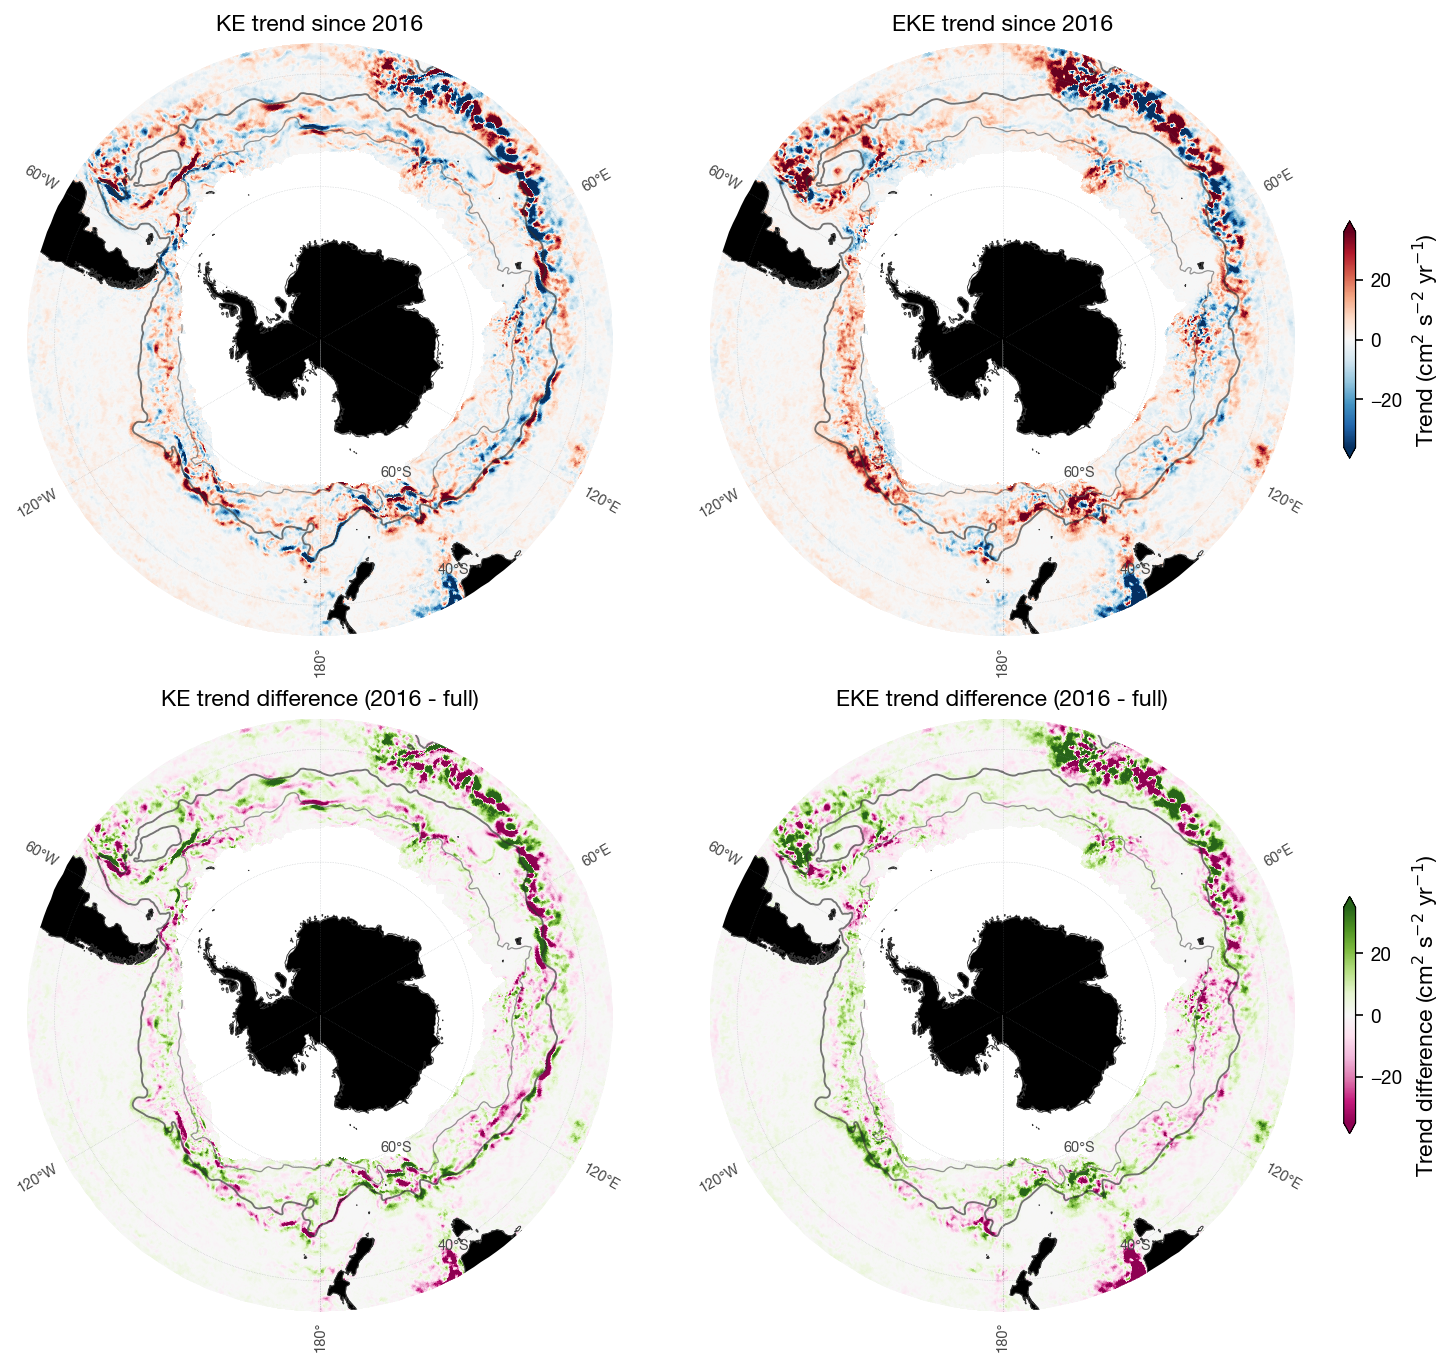

Saved: outputs/plots/trends_split/figA2_2d_trend_since2016_and_difference.png


In [4]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath

full_file = INPUT_TREND_DIR / 'ke_eke_2d_trends.nc'
since2016_file = INPUT_TREND_DIR / 'ke_eke_2d_trends_since2016.nc'

if not full_file.exists():
    raise FileNotFoundError(f'Missing full-period trend file: {full_file}')
if not since2016_file.exists():
    raise FileNotFoundError(f'Missing since-2016 trend file: {since2016_file}')

with xr.open_dataset(full_file) as ds_full, xr.open_dataset(since2016_file) as ds_2016:
    lon = ds_2016['longitude'].values.astype(float)
    lat = ds_2016['latitude'].values.astype(float)
    LON, LAT = np.meshgrid(lon, lat)

    ke_2016 = ds_2016['ke_slope_cm2_s2_yr'].values.astype(float)
    eke_2016 = ds_2016['eke_slope_cm2_s2_yr'].values.astype(float)
    ke_full = ds_full['ke_slope_cm2_s2_yr'].values.astype(float)
    eke_full = ds_full['eke_slope_cm2_s2_yr'].values.astype(float)

# Difference maps: since-2016 minus full-period trend
ke_diff = ke_2016 - ke_full
eke_diff = eke_2016 - eke_full

# ADT for SSH front contours
SSH_ACC_SOUTH = -0.6
SSH_ACC_NORTH = 0.2
acc_levels = [SSH_ACC_SOUTH, SSH_ACC_NORTH]

adt_ds = xr.open_dataset(REPO_ROOT / 'outputs' / 'mean_adt.nc')
adt = adt_ds['mean_adt'].squeeze()
lon_adt = adt['longitude'].values.astype(float)
lat_adt = adt['latitude'].values.astype(float)
if np.nanmax(lon_adt) > 180:
    lon_wrapped = ((lon_adt + 180.0) % 360.0) - 180.0
    ord_lon = np.argsort(lon_wrapped)
    lon_adt = lon_wrapped[ord_lon]
    adt = adt.isel(longitude=ord_lon)
adt_vals = adt.values.astype(float)

# Shared ranges
vmax_2016 = np.nanpercentile(np.abs(np.r_[ke_2016.ravel(), eke_2016.ravel()]), 98)
vmax_diff = np.nanpercentile(np.abs(np.r_[ke_diff.ravel(), eke_diff.ravel()]), 98)
if not np.isfinite(vmax_2016) or vmax_2016 == 0:
    vmax_2016 = 1.0
if not np.isfinite(vmax_diff) or vmax_diff == 0:
    vmax_diff = 1.0

proj = ccrs.SouthPolarStereo()
pc = ccrs.PlateCarree()

fig, axs = plt.subplots(
    2, 2,
    figsize=(10, 9.0),
    subplot_kw={'projection': proj},
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

def style_polar(ax):
    ax.set_extent([-180, 180, -82, -35], crs=pc)
    theta = np.linspace(0, 2 * np.pi, 200)
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * 0.5 + 0.5)
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.add_feature(cfeature.LAND, facecolor='#000000', edgecolor='#555555', linewidth=0.2, zorder=1)
    ax.coastlines('50m', linewidth=0.45, color='#333333')
    gl = ax.gridlines(
        crs=pc, draw_labels=True,
        linewidth=0.30, color='#7A8288', alpha=0.45, linestyle=':',
    )
    gl.xlocator = plt.FixedLocator(range(-180, 181, 60))
    gl.ylocator = plt.FixedLocator([-60, -40])
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 7, 'color': '#4A4A4A'}
    gl.ylabel_style = {'size': 7, 'color': '#4A4A4A'}
    ax.set_frame_on(False)

def add_acc_contours(ax):
    return ax.contour(
        lon_adt, lat_adt, adt_vals,
        levels=acc_levels,
        colors=['#5f5f5f', '#2f2f2f'],
        linewidths=[0.6, 0.9],
        alpha=0.65,
        transform=pc,
        zorder=2,
    )

for ax in axs.ravel():
    style_polar(ax)

# Row 0: Since-2016 trends — KE (left) | EKE (right)
m1 = axs[0, 0].pcolormesh(
    LON, LAT, ke_2016,
    cmap='RdBu_r', vmin=-vmax_2016, vmax=vmax_2016,
    shading='auto', transform=pc, rasterized=True, zorder=0,
)
add_acc_contours(axs[0, 0])
axs[0, 0].set_title('KE trend since 2016')

axs[0, 1].pcolormesh(
    LON, LAT, eke_2016,
    cmap='RdBu_r', vmin=-vmax_2016, vmax=vmax_2016,
    shading='auto', transform=pc, rasterized=True, zorder=0,
)
add_acc_contours(axs[0, 1])
axs[0, 1].set_title('EKE trend since 2016')

# Row 1: Difference maps — KE (left) | EKE (right)
m3 = axs[1, 0].pcolormesh(
    LON, LAT, ke_diff,
    cmap='PiYG', vmin=-vmax_diff, vmax=vmax_diff,
    shading='auto', transform=pc, rasterized=True, zorder=0,
)
add_acc_contours(axs[1, 0])
axs[1, 0].set_title('KE trend difference (2016 - full)')

axs[1, 1].pcolormesh(
    LON, LAT, eke_diff,
    cmap='PiYG', vmin=-vmax_diff, vmax=vmax_diff,
    shading='auto', transform=pc, rasterized=True, zorder=0,
)
add_acc_contours(axs[1, 1])
axs[1, 1].set_title('EKE trend difference (2016 - full)')

# Colorbars: one per row
cb1 = fig.colorbar(m1, ax=[axs[0, 0], axs[0, 1]], shrink=0.4, pad=0.03, extend='both')
cb1.set_label(r'Trend (cm$^2$ s$^{-2}$ yr$^{-1}$)')
cb2 = fig.colorbar(m3, ax=[axs[1, 0], axs[1, 1]], shrink=0.4, pad=0.03, extend='both')
cb2.set_label(r'Trend difference (cm$^2$ s$^{-2}$ yr$^{-1}$)')

adt_ds.close()

# Supplementary figure 'KE_EKE_trends_since2016', top panels (trend + difference maps)
out_map = FIG_DIR / 'KE_EKE_trends_since2016_maps.png'
fig.savefig(out_map, dpi=400, bbox_inches='tight')
plt.show()
print(f'Saved: {out_map}')